# Notebook 03 — Entraînement des modèles & suivi MLflow

## Objectifs
- Comparer plusieurs familles de modèles de classification (baseline → modèles plus puissants)
- Évaluer la robustesse via validation croisée stratifiée (StratifiedKFold)
- Prendre en compte le déséquilibre de classes (pondération / undersampling)
- Optimiser un seuil de décision selon un coût métier (FN >> FP)
- Suivre toutes les expériences avec MLflow (paramètres, métriques, reproductibilité)

## Organisation
- Les entraînements complets sont exécutés via le script CLI `scripts/train_mlflow.py`.
- Ce notebook sert à :
  1) rappeler la méthodologie,
  2) lire/présenter les résultats MLflow,
  3) conclure et préparer l’étape suivante : tuning (Optuna) + explicabilité (SHAP).

In [5]:
import pandas as pd
import numpy as np
import mlflow

from credexp.config import settings
from credexp.modeling.dataset import load_features

In [6]:
ds = load_features()
X, y = ds.X_train, ds.y_train

print("X shape:", X.shape)
print("Default rate (TARGET=1):", y.mean())
y.value_counts()

X shape: (307507, 796)
Default rate (TARGET=1): 0.08072986956394489


TARGET
0    282682
1     24825
Name: count, dtype: int64

## Métriques retenues

En présence d’un fort déséquilibre de classes :
- **ROC AUC** : utile pour mesurer la qualité de ranking globale, mais peut être optimiste.
- **PR AUC** : plus informative quand la classe positive est rare.
- **Coût métier** : on choisit un seuil qui minimise un coût pondéré :
  
  **Cost = FN × cost_fn + FP × cost_fp**

Ici, un faux négatif (accorder un crédit risqué) est plus coûteux qu’un faux positif.

## Entraînement reproductible via CLI

Les entraînements (validation croisée) ont été lancés via :

```bash
uv run python scripts/train_mlflow.py --cv 5
uv run python scripts/train_mlflow.py --cv 5 --undersample
```

Cela garantit :
- reproductibilité,
- stabilité (pas dépendant de l’état du notebook),
- traçabilité MLflow (paramètres + métriques).

## Lecture des résultats MLflow

```bash
 uv run mlflow ui --backend-store-uri ./mlruns
```

On récupère automatiquement les runs depuis MLflow pour :
- comparer les modèles sur les métriques clés,
- identifier le meilleur compromis,
- documenter le choix du modèle retenu.

In [14]:
from pathlib import Path
import mlflow
from mlflow.tracking import MlflowClient

# racine du projet (si ton notebook est dans ./notebooks/)
PROJECT_ROOT = Path.cwd().parent
MLRUNS_DIR = PROJECT_ROOT / "mlruns"

print("Notebook cwd:", Path.cwd())
print("PROJECT_ROOT:", PROJECT_ROOT)
print("MLRUNS_DIR exists:", MLRUNS_DIR.exists(), "->", MLRUNS_DIR)

mlflow.set_tracking_uri(MLRUNS_DIR.resolve().as_uri())
print("Tracking URI set to:", mlflow.get_tracking_uri())

client = MlflowClient()

if hasattr(client, "search_experiments"):
    exps = client.search_experiments()
elif hasattr(client, "list_experiments"):
    exps = client.list_experiments()
else:
    raise RuntimeError("Cannot list experiments with this MLflow version")

print("Experiments found:", len(exps))
for e in sorted(exps, key=lambda x: x.name):
    print(f"- name={e.name!r} id={e.experiment_id} artifact_location={getattr(e, 'artifact_location', None)}")

Notebook cwd: g:\Mon Drive\OC\Projet_6\credexp\notebooks
PROJECT_ROOT: g:\Mon Drive\OC\Projet_6\credexp
MLRUNS_DIR exists: True -> g:\Mon Drive\OC\Projet_6\credexp\mlruns
Tracking URI set to: file:///G:/Mon%20Drive/OC/Projet_6/credexp/mlruns
Experiments found: 7
- name='Default' id=0 artifact_location=./mlruns/0
- name='credexp' id=1 artifact_location=./mlruns/1
- name='credexp_v2' id=2 artifact_location=./mlruns/2
- name='credexp_v2_fix' id=3 artifact_location=./mlruns/3
- name='credexp_v2_fix2' id=4 artifact_location=./mlruns/4
- name='credexp_v2_fix3' id=5 artifact_location=./mlruns/5
- name='credexp_v2_fix4' id=6 artifact_location=./mlruns/6


In [15]:
import pandas as pd

# Remplace éventuellement par le nom exact vu dans la cellule précédente
EXP_NAME = "credexp_v2_fix4"

exp = mlflow.get_experiment_by_name(EXP_NAME)
if exp is None:
    # fallback: prendre l'expérience la plus récente (souvent la bonne)
    exp_df = pd.DataFrame([{"name": e.name, "id": e.experiment_id} for e in exps])
    print("Experiment not found. Available experiments:")
    display(exp_df.sort_values("name"))
    raise ValueError(f"Experiment not found: {EXP_NAME}")

print("Using experiment:", exp.name, "| id:", exp.experiment_id)

Using experiment: credexp_v2_fix4 | id: 6


In [16]:
runs = mlflow.search_runs(
    experiment_ids=[exp.experiment_id],
    output_format="pandas",
)

runs.shape, runs.columns[:10]

((12, 26),
 Index(['run_id', 'experiment_id', 'status', 'artifact_uri', 'start_time',
        'end_time', 'metrics.pr_auc_std', 'metrics.business_cost_mean',
        'metrics.best_threshold_mean', 'metrics.roc_auc_mean'],
       dtype='object'))

In [17]:
cols = [
    "run_id",
    "start_time",
    "tags.mlflow.runName",
    "params.model",
    "params.activation",
    "params.use_undersampling",
    "params.imbalance",
    "metrics.roc_auc_mean",
    "metrics.pr_auc_mean",
    "metrics.business_cost_mean",
    "metrics.best_threshold_mean",
]
available = [c for c in cols if c in runs.columns]

df_results = runs[available].copy()
df_results = df_results.sort_values("metrics.business_cost_mean", ascending=True)
df_results.head(20)

,run_id,start_time,tags.mlflow.runName,params.model,params.activation,params.use_undersampling,params.imbalance,metrics.roc_auc_mean,metrics.pr_auc_mean,metrics.business_cost_mean,metrics.best_threshold_mean
6,0e2abf962c1747a79475070e6c238fc3,2026-02-19 10:14:26.795000+00:00,lgbm,lgbm,,True,balanced,0.782813,0.269348,30397.0,0.530
0,a643f95e67b24913a6a4c5575bbc23e0,2026-02-19 10:47:26.521000+00:00,lgbm,lgbm,,False,balanced,0.781373,0.273479,30452.2,0.368
3,7046baa1be774563af18e919d40a4086,2026-02-19 10:22:37.619000+00:00,lr,lr,,False,balanced,0.773165,0.252933,31115.6,0.514
1,55cb0b8895e84430831611916d4bb54f,2026-02-19 10:32:13.804000+00:00,mlp_logistic,mlp,logistic,False,balanced,0.773247,0.254421,31246.8,0.530
9,ffe4daccccc249b7a79471775fc1308e,2026-02-19 10:03:21.087000+00:00,lr,lr,,True,balanced,0.769696,0.243935,31335.6,0.532
7,6dc931a9f48340119bc3f110fdb7c990,2026-02-19 10:09:00.638000+00:00,mlp_logistic,mlp,logistic,True,balanced,0.770130,0.246887,31488.4,0.518
2,b2eed106351f4408a937b96ef1878296,2026-02-19 10:26:22.068000+00:00,mlp_relu,mlp,relu,False,balanced,0.765101,0.244804,31964.6,0.498
8,b7f1fd9a4e85485f99a639d01517373a,2026-02-19 10:05:54.777000+00:00,mlp_relu,mlp,relu,True,balanced,0.757023,0.229641,32690.2,0.530
5,8b6d3d4e57524083b9912d0b057f2cec,2026-02-19 10:18:37.134000+00:00,dummy_most_frequent,dummy,most_frequent,False,balanced,0.500000,0.080730,49650.0,0.010
11,596cdbf12f98451abcbfcc0911ee63a9,2026-02-19 09:59:13.325000+00:00,dummy_most_frequent,dummy,most_frequent,True,balanced,0.500000,0.080730,49650.0,0.010


### Comment lire ce tableau ?
- `business_cost_mean` est la métrique métier : plus bas = meilleur.
- `roc_auc_mean` et `pr_auc_mean` donnent une vue complémentaire (ranking global vs classe rare).
- `best_threshold_mean` correspond au seuil optimisé sur le coût métier (moyenné sur les folds).
- Les baselines Dummy doivent être largement battues par tout modèle “sérieux”.

In [18]:
# Normaliser un nom lisible
def pretty_name(row):
    name = row.get("tags.mlflow.runName", "")
    under = row.get("params.use_undersampling", "")
    return f"{name} | undersample={under}"

df_results["pretty"] = df_results.apply(pretty_name, axis=1)

# meilleur run global
best = df_results.iloc[0]
best[["pretty", "metrics.business_cost_mean", "metrics.roc_auc_mean", "metrics.pr_auc_mean", "metrics.best_threshold_mean"]]

pretty                         lgbm | undersample=True
metrics.business_cost_mean                     30397.0
metrics.roc_auc_mean                          0.782813
metrics.pr_auc_mean                           0.269348
metrics.best_threshold_mean                       0.53
Name: 6, dtype: object

In [19]:
df_results[["pretty", "metrics.business_cost_mean", "metrics.roc_auc_mean", "metrics.pr_auc_mean", "metrics.best_threshold_mean"]].head(10)

,pretty,metrics.business_cost_mean,metrics.roc_auc_mean,metrics.pr_auc_mean,metrics.best_threshold_mean
6,lgbm | undersample=True,30397.0,0.782813,0.269348,0.530
0,lgbm | undersample=False,30452.2,0.781373,0.273479,0.368
3,lr | undersample=False,31115.6,0.773165,0.252933,0.514
1,mlp_logistic | undersample=False,31246.8,0.773247,0.254421,0.530
9,lr | undersample=True,31335.6,0.769696,0.243935,0.532
7,mlp_logistic | undersample=True,31488.4,0.770130,0.246887,0.518
2,mlp_relu | undersample=False,31964.6,0.765101,0.244804,0.498
8,mlp_relu | undersample=True,32690.2,0.757023,0.229641,0.530
5,dummy_most_frequent | undersample=False,49650.0,0.500000,0.080730,0.010
11,dummy_most_frequent | undersample=True,49650.0,0.500000,0.080730,0.010


## Synthèse & choix du modèle

D’après les runs MLflow (validation croisée) :

- Les baselines Dummy (most_frequent, stratified) servent de contrôle minimal.
- La Logistic Regression fournit une baseline interprétable.
- Les modèles boosting (LightGBM) obtiennent généralement le meilleur compromis sur données tabulaires.
- Le MLP sert de comparaison “réseau de neurones” (2 activations demandées).

**Modèle retenu à ce stade (avant tuning)** :  
➡️ **LightGBM sans undersampling**

Critère principal : minimisation de `business_cost_mean` et robustesse (faible variance, métriques stables).

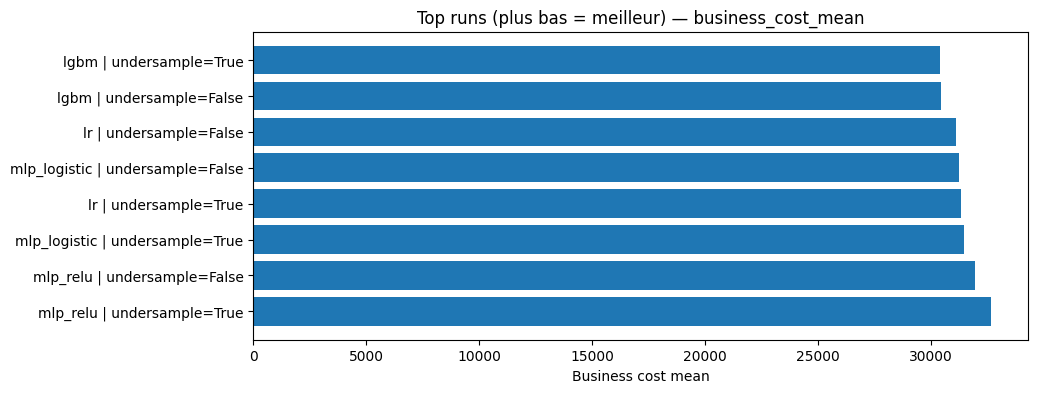

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

topn = 8
tmp = df_results.head(topn).copy()

plt.figure(figsize=(10, 4))
plt.barh(tmp["pretty"], tmp["metrics.business_cost_mean"])
plt.gca().invert_yaxis()
plt.title("Top runs (plus bas = meilleur) — business_cost_mean")
plt.xlabel("Business cost mean")
plt.show()